In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data cleaning

In [96]:
# df = pd.read_excel("MD_agric_dataset_final-1.xlsx")
df = pd.read_csv("MD_agric_exam-4313.csv")
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava


In [97]:
# remove spaces from column names
df.columns = df.columns.str.replace(' ', '', regex=False)

# remove ALL spaces from string values in all object columns
df = df.apply(lambda col: col.str.replace(' ', '', regex=False) if col.dtype == 'object' else col)

# remove all the spaces from the 'Crop_type' column
df['Crop_type'] = df['Crop_type'].str.replace(' ', '', regex=False)

In [98]:
# information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Field_ID           1000 non-null   int64  
 1   Elevation          1000 non-null   float64
 2   Rainfall           1000 non-null   float64
 3   Min_temperature_C  1000 non-null   float64
 4   Max_temperature_C  1000 non-null   float64
 5   pH                 1000 non-null   float64
 6   Pollution_level    1000 non-null   float64
 7   Plot_size          1000 non-null   float64
 8   Annual_yield       1000 non-null   float64
 9   Crop_type          1000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 83.6 KB


In [99]:
# isnull() method to check for missing values in the dataset
df.isnull().sum()

Field_ID             0
Elevation            0
Rainfall             0
Min_temperature_C    0
Max_temperature_C    0
pH                   0
Pollution_level      0
Plot_size            0
Annual_yield         0
Crop_type            0
dtype: int64

In [100]:
# isna() method to check for missing values in the dataset
df.isna().sum()

Field_ID             0
Elevation            0
Rainfall             0
Min_temperature_C    0
Max_temperature_C    0
pH                   0
Pollution_level      0
Plot_size            0
Annual_yield         0
Crop_type            0
dtype: int64

In [101]:
df.describe()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,2779.486000,628.136035,1197.734700,-4.504100,30.89460,5.603899,2.233740e-01,3.962400,2.101536
std,1595.068372,179.098546,497.794699,1.568117,1.92225,0.802154,2.288665e-01,3.459036,1.926694
min,1.000000,35.910797,110.100000,-9.700000,25.10000,3.701838,5.397448e-10,0.500000,0.174857
25%,1442.250000,504.392825,771.575000,-5.600000,29.57500,5.018775,4.449419e-02,1.500000,0.786612
50%,2728.500000,657.468975,1194.900000,-4.400000,30.90000,5.562078,1.661962e-01,2.900000,1.478622
75%,4133.000000,761.075752,1616.900000,-3.300000,32.20000,6.201437,3.077840e-01,4.700000,2.519811
max,5632.000000,1003.943700,2408.500000,-1.200000,37.30000,7.484683,9.954134e-01,15.000000,12.695224


In [102]:
# value counts for all the columns in the dataset
for col in df.columns:
    print("=" * 70)
    print(f"Value counts for column '{col}':")
    print(df[col].value_counts())
    print("\n")

Value counts for column 'Field_ID':
Field_ID
1162    1
5108    1
3504    1
5351    1
905     1
       ..
2202    1
2531    1
1040    1
58      1
3334    1
Name: count, Length: 1000, dtype: int64


Value counts for column 'Elevation':
Elevation
636.22640    2
494.95615    1
663.73390    1
396.87990    1
594.80370    1
            ..
572.95935    1
552.80945    1
678.22504    1
792.65370    1
747.69850    1
Name: count, Length: 999, dtype: int64


Value counts for column 'Rainfall':
Rainfall
1717.5    3
1350.4    3
1649.3    2
1835.2    2
1731.1    2
         ..
625.6     1
398.1     1
564.4     1
928.5     1
981.5     1
Name: count, Length: 976, dtype: int64


Value counts for column 'Min_temperature_C':
Min_temperature_C
-4.0    33
-3.3    30
-4.9    30
-3.9    29
-2.9    25
        ..
-1.4     1
-7.6     1
-9.7     1
-9.2     1
-7.9     1
Name: count, Length: 78, dtype: int64


Value counts for column 'Max_temperature_C':
Max_temperature_C
30.7    26
31.0    25
30.5    24
31.5    23
3

In [103]:
df.columns

Index(['Field_ID', 'Elevation', 'Rainfall', 'Min_temperature_C',
       'Max_temperature_C', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type'],
      dtype='str')

In [104]:
categorical_columns = df.select_dtypes(include=[object]).columns.tolist()
categorical_columns

C:\Users\Anthony\AppData\Local\Temp\ipykernel_2408\1109842299.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=[object]).columns.tolist()


['Crop_type']

In [105]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_columns

['Field_ID',
 'Elevation',
 'Rainfall',
 'Min_temperature_C',
 'Max_temperature_C',
 'pH',
 'Pollution_level',
 'Plot_size',
 'Annual_yield']

In [106]:
# checking for duplicates in the dataset
df.duplicated().sum()

np.int64(0)

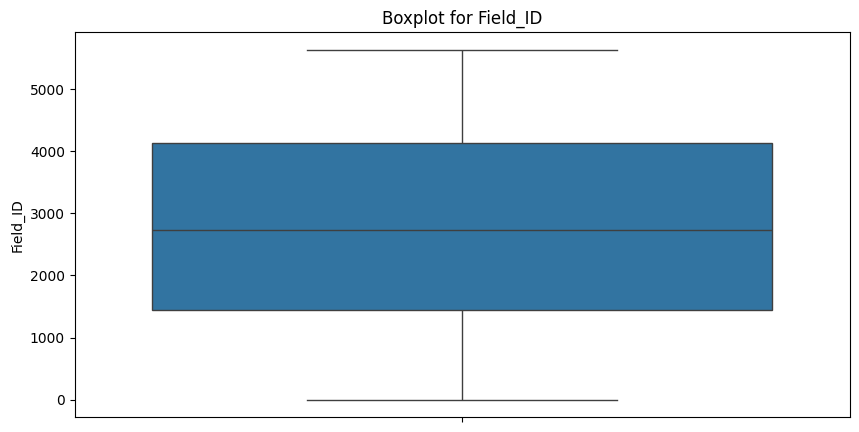

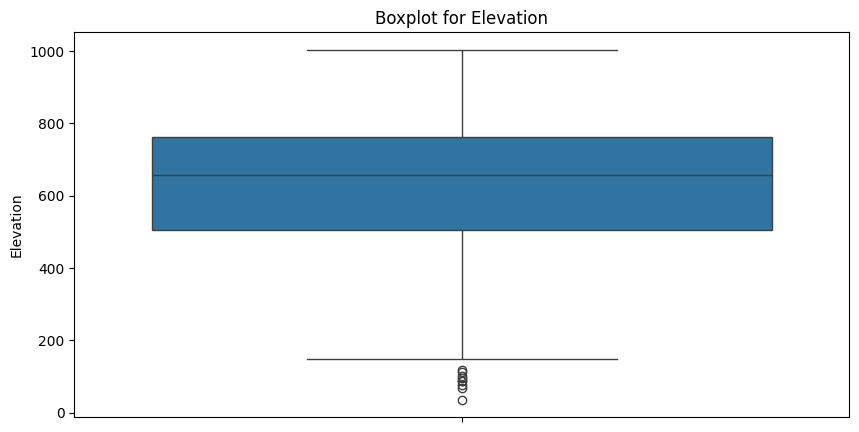

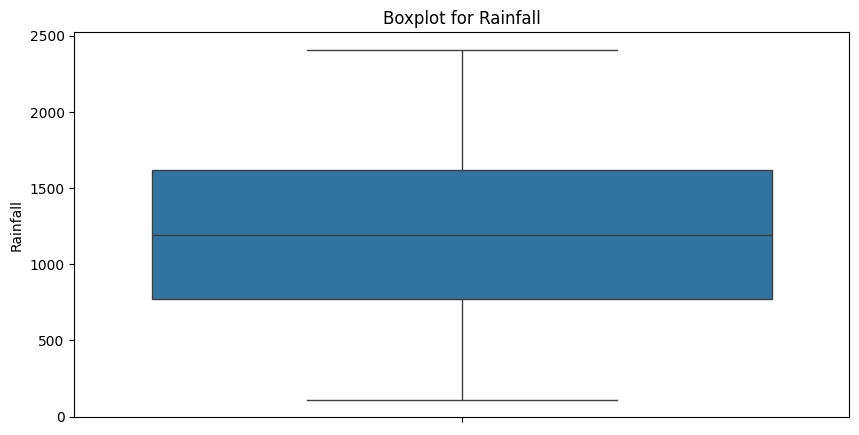

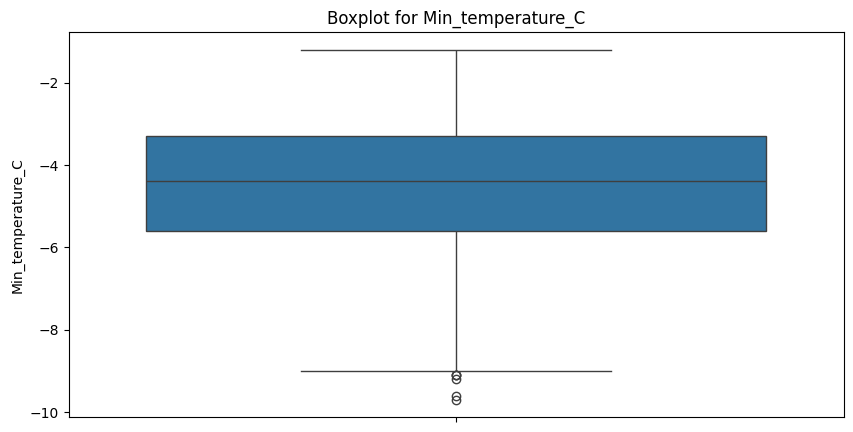

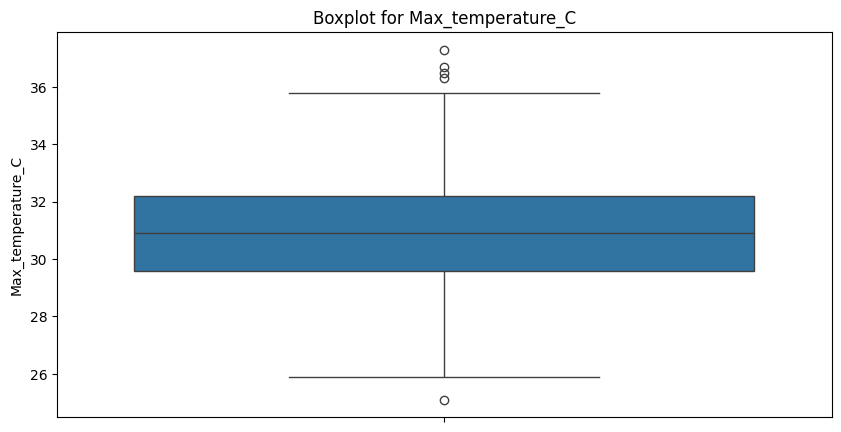

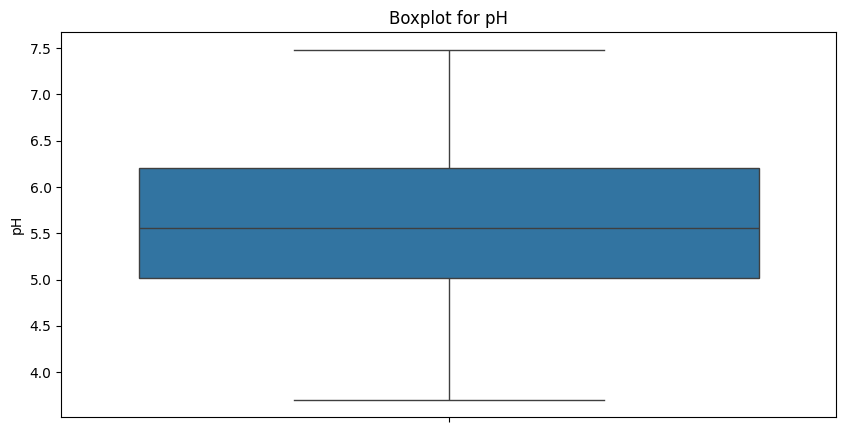

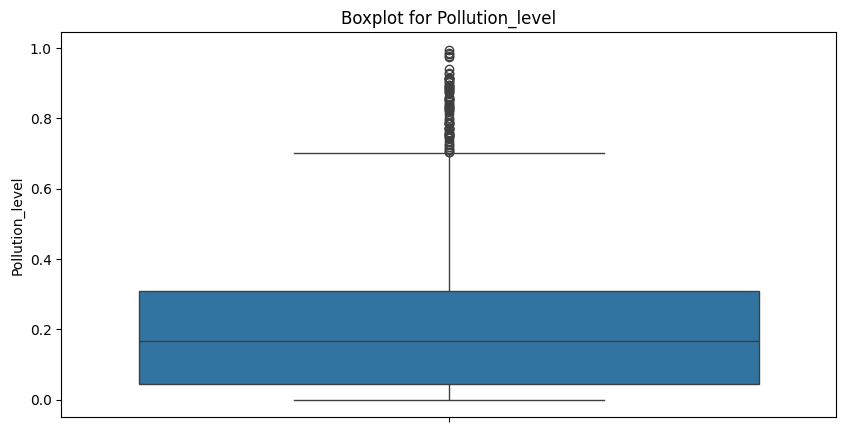

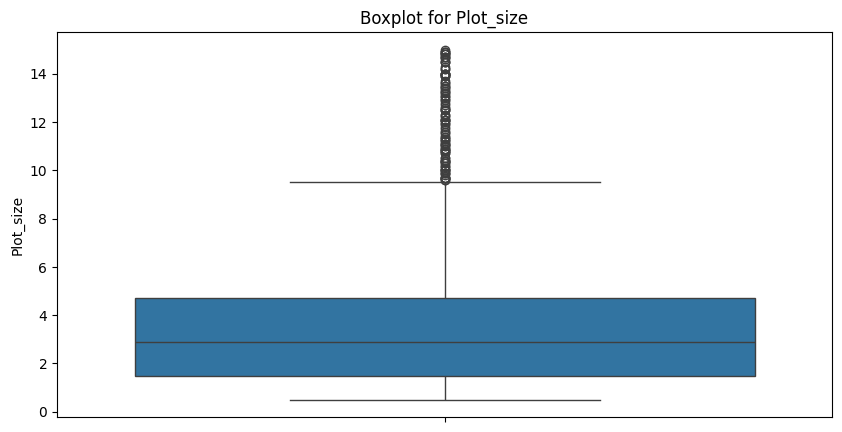

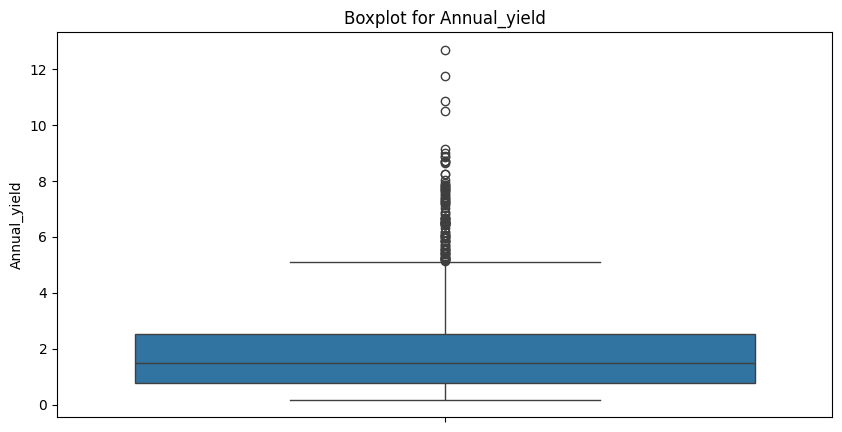

In [107]:
# check for the  outliers in the numerical columns using boxplots
for col in numerical_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

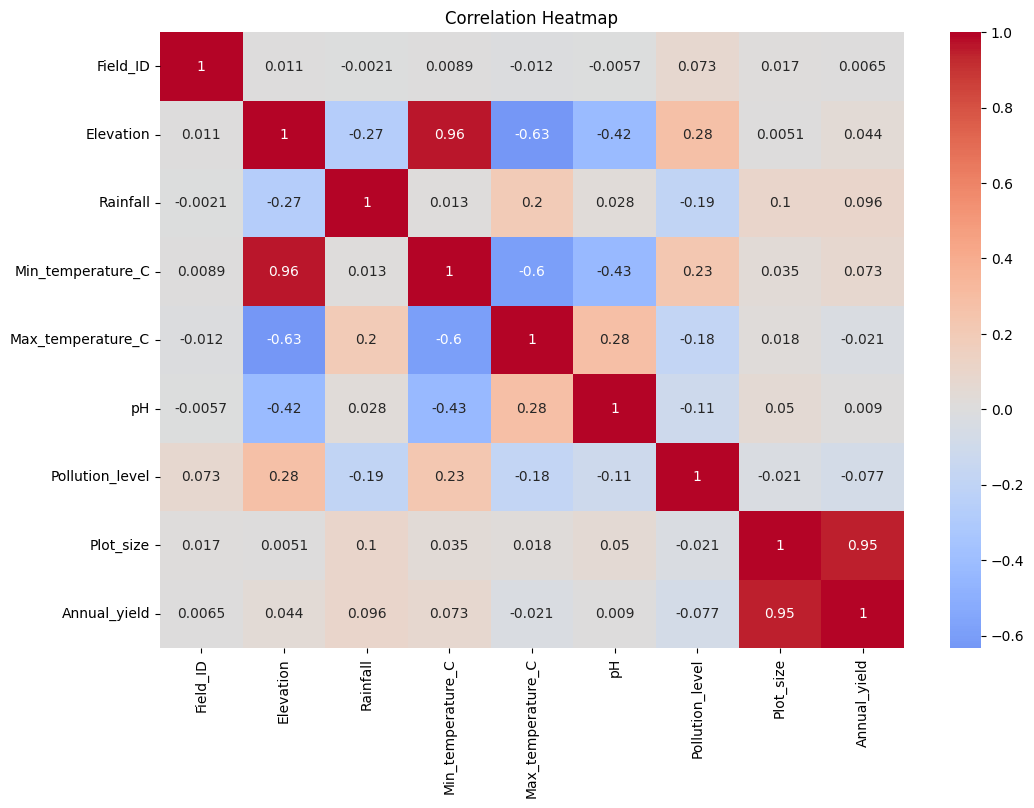

In [108]:
# advance correlation analysis using heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

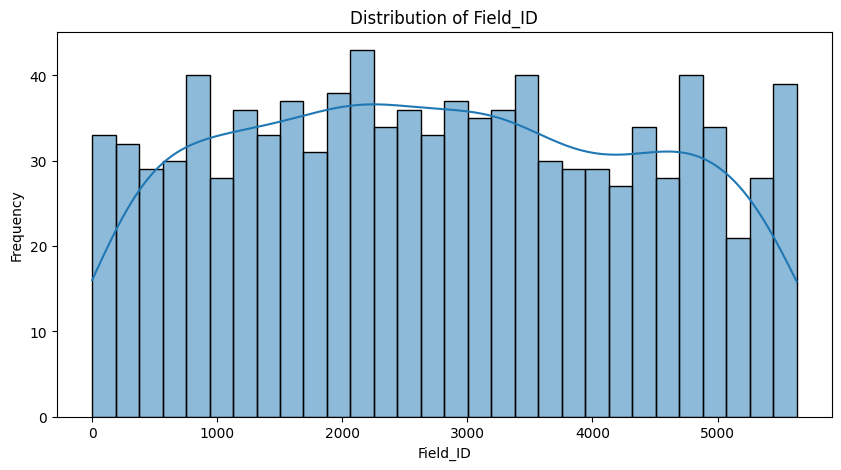

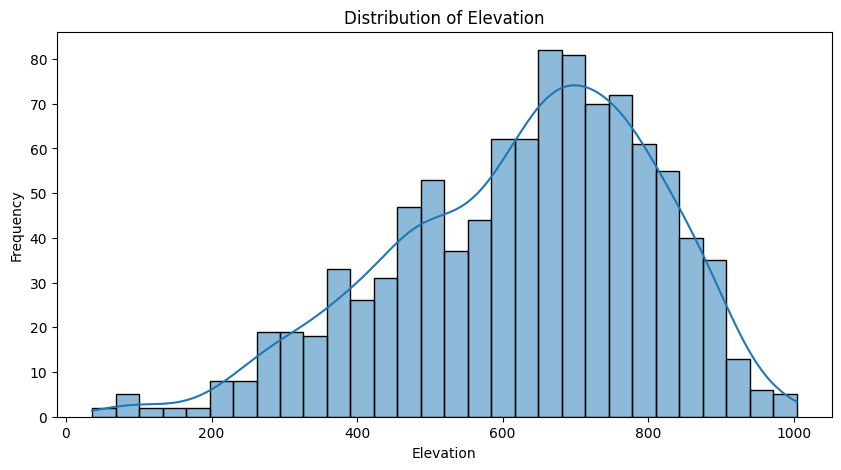

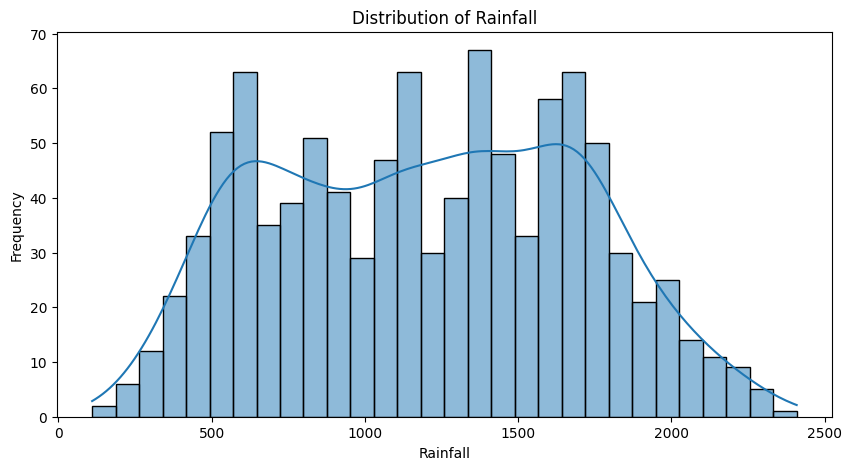

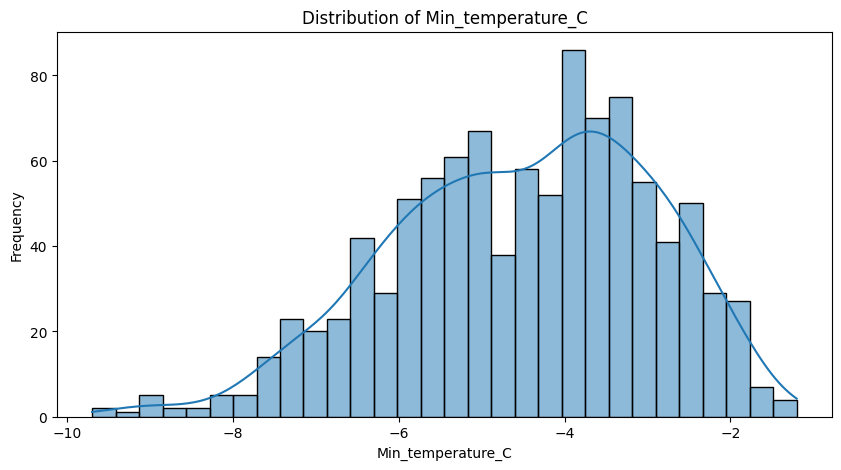

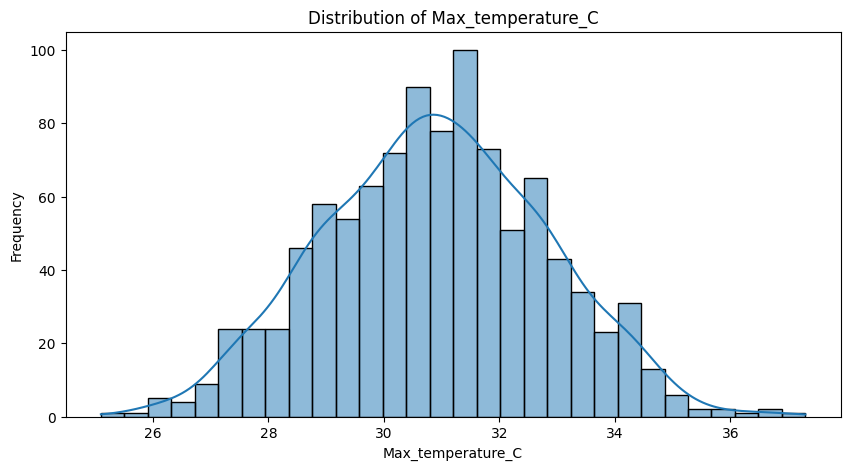

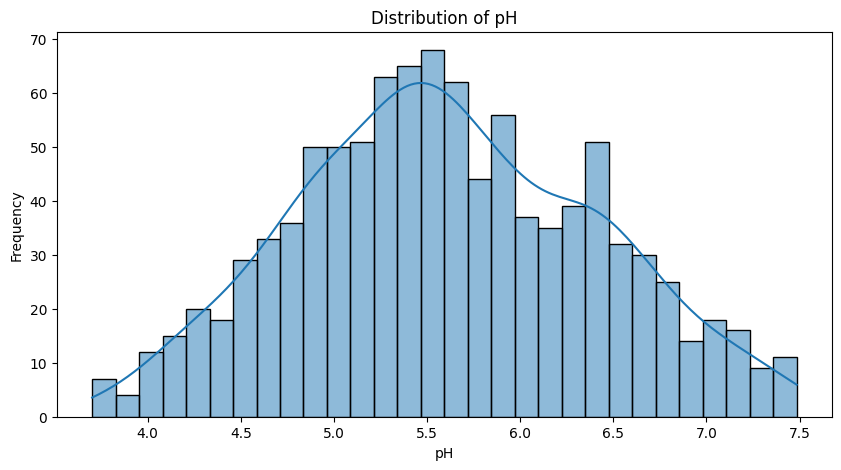

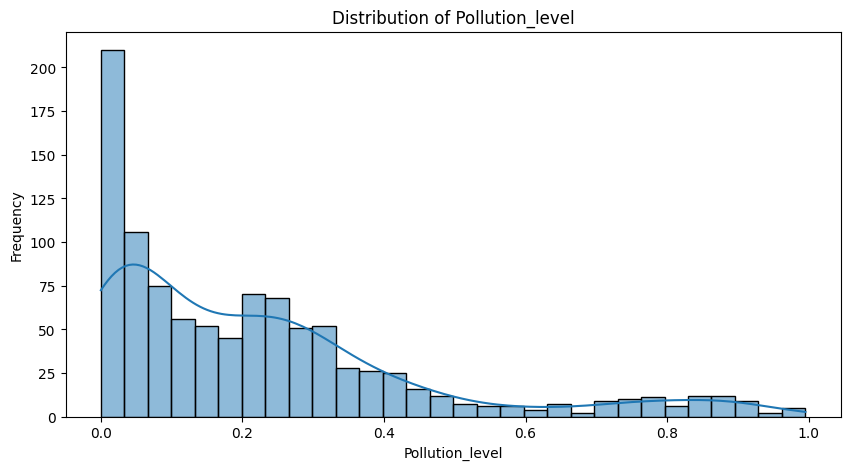

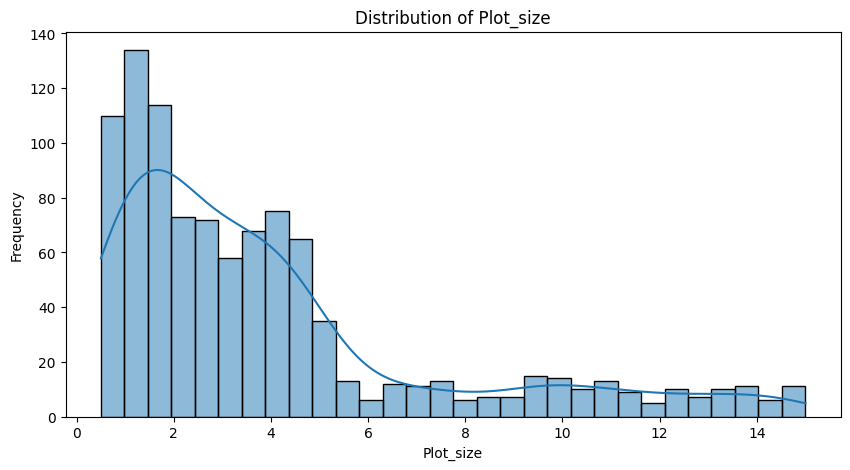

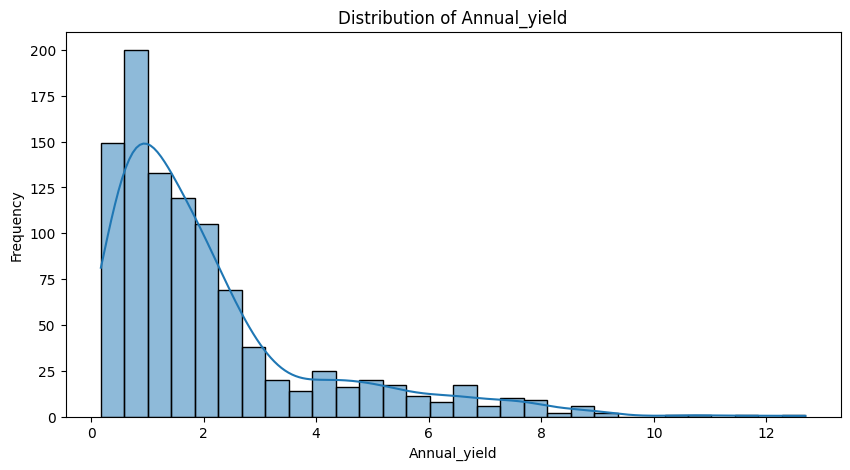

In [109]:
# distribution of numerical columns using histograms
for col in numerical_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# 1. Write code to determine the number of unique crop types in the dataset?

In [110]:
# remove all the spaces from the 'Crop_type' column
df['Crop_type'] = df['Crop_type'].str.replace(' ', '', regex=False)

In [111]:
# unique values in the 'Crop_type' column
unique_crops = df['Crop_type'].nunique()
unique_crops

8

In [112]:
all_crops = df['Crop_type'].unique()
all_crops

<ArrowStringArray>
['coffee', 'potato', 'banana', 'wheat', 'cassava', 'maize', 'tea', 'rice']
Length: 8, dtype: str

# 2. Identify the maximum annual yield for "wheat" crop type in the dataset (rounded to 2 decimal places).

In [113]:
wheat_max = df[df['Crop_type'] == 'wheat']['Annual_yield'].max()
wheat_min = df[df['Crop_type'] == 'wheat']['Annual_yield'].min()

print(f"Maximum Annual Yield for Wheat: {wheat_max}")
print(f"Minimum Annual Yield for Wheat: {wheat_min}")

Maximum Annual Yield for Wheat: 8.994376295629458
Minimum Annual Yield for Wheat: 0.1748574333801564


In [114]:
# maximum  and minimum annual yield for each crop type
max_yield = df.groupby('Crop_type')['Annual_yield'].max().round(2)
min_yield = df.groupby('Crop_type')['Annual_yield'].min().round(2)

print(f"Maximum Annual Yield for each Crop Type: {max_yield.name}")
print(max_yield)
print(f"Minimum Annual Yield for each Crop Type: {min_yield.name}")
print(min_yield)

Maximum Annual Yield for each Crop Type: Annual_yield
Crop_type
banana      7.44
cassava     7.73
coffee      7.36
maize       8.65
potato      8.87
rice       10.51
tea        12.70
wheat       8.99
Name: Annual_yield, dtype: float64
Minimum Annual Yield for each Crop Type: Annual_yield
Crop_type
banana     0.19
cassava    0.19
coffee     0.26
maize      0.26
potato     0.33
rice       0.31
tea        0.22
wheat      0.17
Name: Annual_yield, dtype: float64


# 3. Find the total rainfall for crop types where the average pollution level is above 0.2. 

In [115]:
df.columns

Index(['Field_ID', 'Elevation', 'Rainfall', 'Min_temperature_C',
       'Max_temperature_C', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type'],
      dtype='str')

In [116]:
# Find the total rainfall for crop types where the average pollution level is above 0.2.
# Find crop types with average pollution level > 0.2
high_pollution_crops = (
    df.groupby('Crop_type')['Pollution_level']
      .mean()
      .loc[lambda x: x > 0.2]
      .index
)

# Calculate total rainfall for those crop types
total_rainfall = (
    df[df['Crop_type'].isin(high_pollution_crops)]
      .groupby('Crop_type')['Rainfall']
      .sum()
)

print(total_rainfall)

Crop_type
cassava    178709.1
coffee     148849.5
maize       57184.0
potato      93860.2
tea        210650.5
wheat      252706.4
Name: Rainfall, dtype: float64


In [117]:
# sum the total rainfall for crop types where the average pollution level is above 0.2.
total_rainfall_sum = total_rainfall.sum()
total_rainfall_sum

np.float64(941959.7000000001)

# 4. Write a function to calculate the temperature range (Max_temperature_C - Min_temperature_C) for each farmer's field. Then, call the function with the following `Field_ID`: `1458`, `1895`, and `5443`. What are the results of these 3 calls?

In [118]:
df.columns

Index(['Field_ID', 'Elevation', 'Rainfall', 'Min_temperature_C',
       'Max_temperature_C', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type'],
      dtype='str')

In [119]:
df[['Min_temperature_C', 'Max_temperature_C', 'Rainfall', 'Pollution_level']].head()

,Min_temperature_C,Max_temperature_C,Rainfall,Pollution_level
0,-5.4,31.0,1507.6,0.007034
1,-4.7,30.9,581.0,0.289643
2,-6.1,31.7,1715.1,0.000409
3,-4.3,33.6,1748.0,0.088777
4,-4.5,31.3,1395.8,0.050023


In [120]:
"""
Write a function to calculate the temperature range (Max_temperature_C - Min_temperature_C) for each farmer's field. 
Then, call the function with the following `Field_ID`: `1458`, `1895`, and `5443`. What are the results of these 3 calls?
"""
def calculate_temperature_range(field_id):
    # Convert field_id to string
    field_id = str(field_id)

    # Filter rows where Field_ID starts with the given digits
    field_data = df[df['Field_ID'].astype(str).str.startswith(field_id)]

    if not field_data.empty:
        # Calculate the range for all matching rows
        max_temp = field_data['Max_temperature_C'].max()
        min_temp = field_data['Min_temperature_C'].min()
        temp_range = max_temp - min_temp

        return field_id, temp_range
    else:
        return field_id, None


# Call the function
result_1458 = calculate_temperature_range(1458)
result_1895 = calculate_temperature_range(1895)
result_5443 = calculate_temperature_range(5443)

result_1458, result_1895, result_5443

(('1458', np.float64(40.7)),
 ('1895', np.float64(35.7)),
 ('5443', np.float64(33.4)))

In [121]:
a = df['Crop_type'].unique()

b = float('inf')

c = ''

for crop in a:

    d = df[df['Crop_type'] == crop]['Min_temperature_C'].mean()

    if d < b:

        b = d

        c = crop

print(c)

rice


# 5. Write code to calculate the total plot size for plots where the pH is less than 5.5.

In [122]:
df.columns

Index(['Field_ID', 'Elevation', 'Rainfall', 'Min_temperature_C',
       'Max_temperature_C', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type'],
      dtype='str')

In [123]:
# Write code to calculate the total plot size for plots where the pH is less than 5.5.
total_plot_size = df[df['pH'] < 5.5]['Plot_size'].sum()
print(f"Total plot size for plots with pH < 5.5: {total_plot_size}")

Total plot size for plots with pH < 5.5: 1731.8999999999999


# 6. Using Pandas, create a dataframe that includes entries with a 'Min_temperature_C’< -5 and a 'Max_temperature_C' > 30. How many rows are in the filtered dataset?

In [124]:
""" 
Using Pandas, create a dataframe that includes entries with a 'Min_temperature_C’< -5 and a 'Max_temperature_C' > 30. 
How many rows are in the filtered dataset?
"""
df_filtered = df[(df['Min_temperature_C'] < -5) & (df['Max_temperature_C'] > 30)]
print(f"Number of rows in the filtered dataset: {len(df_filtered)}")

Number of rows in the filtered dataset: 319


In [125]:
df_filtered

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
5,2274,270.45100,1665.2,-7.2,34.3,5.873082,0.001545,3.9,1.743458,banana
13,4807,520.29770,292.3,-6.3,32.9,5.379286,0.196589,1.4,0.881568,potato
14,973,432.03570,1464.4,-6.0,30.2,7.482802,0.019800,3.0,1.377434,wheat
...,...,...,...,...,...,...,...,...,...,...
990,1637,504.66306,1144.5,-5.7,32.1,5.666609,0.431891,4.8,2.486276,wheat
991,756,578.91270,889.4,-5.2,31.0,5.062155,0.442495,2.2,1.209928,cassava
992,1332,359.76013,1816.0,-6.4,32.9,7.350705,0.133453,2.9,1.225715,wheat
995,2202,572.95935,625.6,-5.5,31.0,5.258964,0.086330,1.2,0.750675,wheat


# 7. Using Numpy, calculate the standard deviation of the 'Rainfall' for plots where the 'Plot_size' is larger than the median plot size of the dataset (round to 2 decimal places).

In [128]:
""" 
Using Numpy, calculate the standard deviation of the 'Rainfall' for plots where the 'Plot_size' is larger 
than the median plot size of the dataset (round to 2 decimal places).
"""

median_plot_size = np.median(df['Plot_size'])
filtered_rainfall = df[df['Plot_size'] > median_plot_size]['Rainfall']
std_deviation = np.std(filtered_rainfall, ddof=0)  # Using ddof=0 for population standard deviation
std_deviation = round(std_deviation, 2)
std_deviation

np.float64(469.62)

# 8. If you concatenate the first three digits of the most common ‘Max_temperature_C’ with the last three letters of the least common 'Crop_type', what string do you get?
Note: Use the first mode if there are multiple modes

In [129]:
"""  
If you concatenate the first three digits of the most common ‘Max_temperature_C’ with the last three letters of the least common 'Crop_type', what string do you get?
Note: Use the first mode if there are multiple modes
"""
most_common_temp = df['Max_temperature_C'].mode().iloc[0]
least_common_crop = df['Crop_type'].value_counts().index[-1]
result = str(most_common_temp)[:3] + least_common_crop[-3:]
result

'30.ice'

# 10 Write Python code to create a violin plot visualising the distribution of 'Annual_yield' across different 'Elevation' ranges. Use the provided elevation range categories (Low: < 300m, Medium: 300m - 600m, High: > 600m) to categorise the data before plotting.  Examine the violin plot displaying the distribution of 'Annual Yield' across three elevation categories (Low, Medium, High). What insight does the violin plot provide regarding the relationship between elevation ranges and annual yield distribution?

In [130]:
df.columns

Index(['Field_ID', 'Elevation', 'Rainfall', 'Min_temperature_C',
       'Max_temperature_C', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type'],
      dtype='str')

In [134]:
df['Annual_yield']

0      1.617421
1      2.532497
2      1.262207
3      4.351564
4      5.034791
         ...   
995    0.750675
996    0.449790
997    0.492988
998    0.597557
999    2.867815
Name: Annual_yield, Length: 1000, dtype: float64

In [132]:
# df['Elevation'].unique()

Medium elevation exhibits a variability in yield, but to a significantly lesser extent than the High elevation, potentially due to a mix of conditions that affect crop yield.”

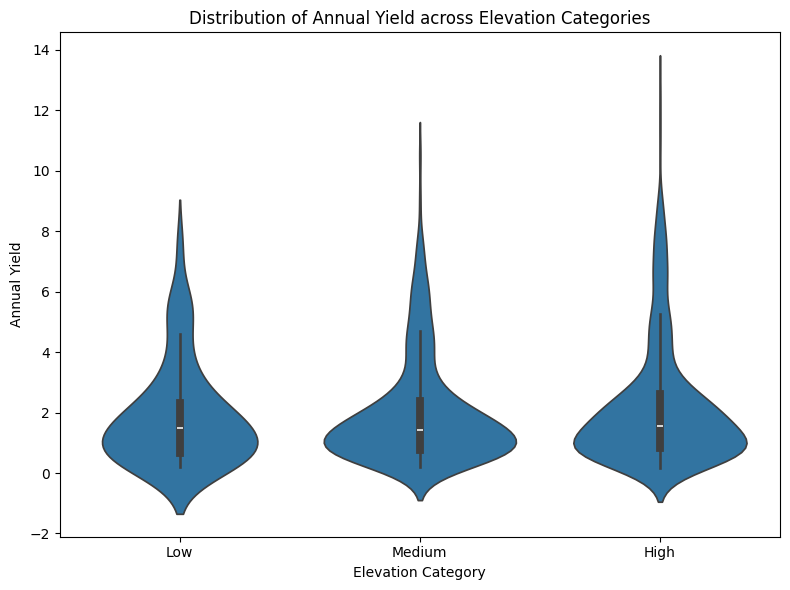

In [136]:
""" 
Write Python code to create a violin plot visualising the distribution of 'Annual_yield' across different 'Elevation' ranges. Use the provided elevation range categories (Low: < 300m, Medium: 300m - 600m, High: > 600m) to categorise the data before plotting.  Examine the violin plot displaying the distribution of 'Annual Yield' across three elevation categories (Low, Medium, High). 
What insight does the violin plot provide regarding the relationship between elevation ranges and annual yield distribution?
"""
violin_df = df.copy()

# Categorize Elevation using the prompt's thresholds
violin_df['Elevation_Category'] = np.where(
    violin_df['Elevation'] < 300,
    'Low',
    np.where(violin_df['Elevation'] <= 600, 'Medium', 'High')
)

plt.figure(figsize=(8, 6))
sns.violinplot(
    x='Elevation_Category',
    y='Annual_yield',
    data=violin_df,
    order=['Low', 'Medium', 'High']
)
plt.title('Distribution of Annual Yield across Elevation Categories')
plt.xlabel('Elevation Category')
plt.ylabel('Annual Yield')
plt.tight_layout()
plt.show()

Medium elevation exhibits a variability in yield, but to a significantly lesser extent than the High elevation, potentially due to a mix of conditions that affect crop yield.

# 11. Assuming each 'Crop_type' contributes an integer value equal to its length (e.g., 'wheat' contributes 5), write a recursive function to sum the integer values for each unique crop type in the dataset. What is the sum?

In [138]:
# Uniques crop types
unique_crops = df['Crop_type'].unique()
print(f"Unique crop types: {unique_crops}")

Unique crop types: <ArrowStringArray>
['coffee', 'potato', 'banana', 'wheat', 'cassava', 'maize', 'tea', 'rice']
Length: 8, dtype: str


In [137]:
""" 
Assuming each 'Crop_type' contributes an integer value equal to its length (e.g., 'wheat' contributes 5), 
write a recursive function to sum the integer values for each unique crop type in the dataset. What is the sum?
"""
def sum_crop_types(crop_types):
    if not crop_types:
        return 0
    else:
        return len(crop_types[0]) + sum_crop_types(crop_types[1:])

sum_crop_types(df['Crop_type'].unique())

42

# 12. Write Python code to perform a t-test comparing the average 'Annual_yield' between 'coffee' and 'banana' crop types using scipy.stats. What is the p-value, rounded to three decimal places?

In [139]:
""" 
Write Python code to perform a t-test comparing the average 'Annual_yield' between 'coffee' and 'banana' crop types using scipy.stats. 
What is the p-value, rounded to three decimal places?
"""
import scipy.stats as stats

coffee_yield = df[df['Crop_type'] == 'coffee']['Annual_yield']
banana_yield = df[df['Crop_type'] == 'banana']['Annual_yield']
t_stat, p_value = stats.ttest_ind(coffee_yield, banana_yield)
print(f"P-value: {p_value:.3f}")

P-value: 0.598


In [140]:
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")

t-statistic: -0.528, p-value: 0.598


In [146]:
def add(*rgs):
    c = rgs[0] + rgs[1]
    return c

add(2, 3)

5